In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler,Normalizer,MaxAbsScaler
from hdbscan import HDBSCAN

#  carregar dados
df = pd.read_csv('/content/matriz_risco_fundos.csv', sep=',')

# identificar as colunas
colunas_originais = df.columns[-3:].tolist()
print(f"Colunas utilizadas para clusterização: {colunas_originais}")

# preparar dados e escalonar
dados = df[colunas_originais].values
scaler =  StandardScaler()
dados_esc = scaler.fit_transform(dados)

#criar e treinar o HDBSCAN
hdbscan = HDBSCAN(
    cluster_selection_epsilon=0.0,
    gen_min_span_tree=True,
    min_cluster_size=5,
    min_samples=6
)
df['cluster_hdbscan'] = hdbscan.fit_predict(dados_esc)

#  exibir a validade relativa
print(f"\nDBCV): {hdbscan.relative_validity_:.4f}")


#salvar o resultado final
df.to_csv('matriz_final', index=False)
print("\n matriz escrita")


Colunas utilizadas para clusterização: ['DIAS_OPERADOS', 'RETORNO_MEDIO_DIARIO', 'VOLATILIDADE_RISCO']

DBCV): 0.2665

 matriz escrita


           CNPJ_FUNDO  DIAS_OPERADOS  RETORNO_MEDIO_DIARIO  \
0  17.940.400/0001-80            102              0.000216   
1  34.231.938/0001-34            102              0.000415   
2  30.419.203/0001-88            102              0.000521   
3  35.602.471/0001-54            102              0.000214   
4  40.944.483/0001-05            102              0.000946   

   VOLATILIDADE_RISCO  cluster_hdbscan  
0            0.001861               91  
1            0.002841               69  
2            0.000006               -1  
3            0.009897               -1  
4            0.005417               -1  
[ 91  69  -1  83  57 112  44 115 110  10 127   4  52   3  29  32 100  19
  55 129  59 103   6  28  40 117  58  64  31  70 135  23  94 109 119  26
 125  67  82   2 124  99  24  86 132 136  84  96  92  75 122  30  16  71
  21  20 131  90  72  78  47  66 105   9  76  87  77  46  93  41 126  33
 130 113  81 118  38  49  39 134   8  17  61  35  36  85  73 101  68  25
  97  48  56  18

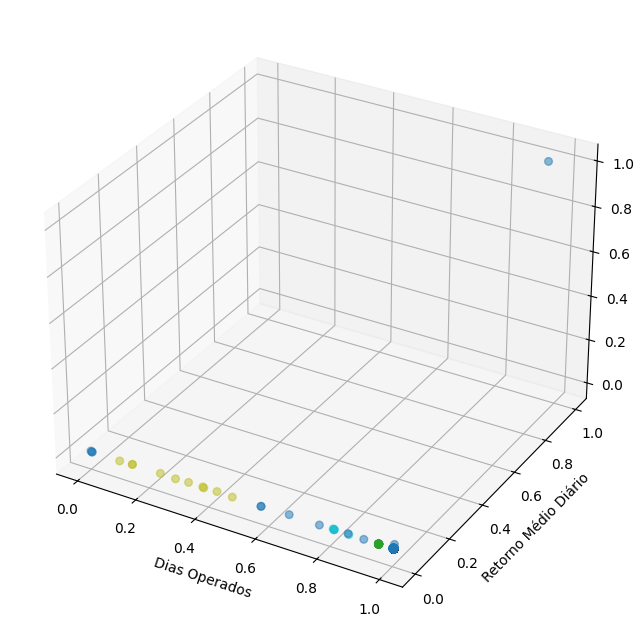

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
#exibe informações basicas
df = pd.read_csv('/content/matriz_final')
print(df.head())
grupos = df['cluster_hdbscan'].unique()
print(grupos)
#normalizar
cols_normalizar = ['DIAS_OPERADOS', 'RETORNO_MEDIO_DIARIO', 'VOLATILIDADE_RISCO']
for col in cols_normalizar:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col + '_norm'] = (df[col] - min_val) / (max_val - min_val)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
cores = plt.cm.tab10(np.linspace(0, 1, len(grupos)))

# Plotar cada grupo com uma cor diferente
for i, grupo in enumerate(grupos):
    df_grupo = df[df['cluster_hdbscan'] == grupo]
    print(f"Grupo {grupo}: {len(df_grupo)} membros")
    ax.scatter(
        df_grupo['DIAS_OPERADOS_norm'],
        df_grupo['RETORNO_MEDIO_DIARIO_norm'],
        df_grupo['VOLATILIDADE_RISCO_norm'],
        color=cores[i],
        label=f'Grupo {grupo}',
        alpha=0.5,
        s=30
    )
print(len(grupos))
ax.set_xlabel('Dias Operados')
ax.set_ylabel('Retorno Médio Diário')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler,Normalizer,MaxAbsScaler
from hdbscan import HDBSCAN

# carregar dados
df = pd.read_csv('/content/matriz_risco_fundos.csv', sep=',')

# remover coluna de dias
df = df.drop(columns=['DIAS_OPERADOS'], errors='ignore')

# identificar as colunas
colunas_originais = df.columns[-2:].tolist()
print(f"Colunas utilizadas para clusterização: {colunas_originais}")

# preparar dados e escalonar
dados = df[colunas_originais].values
scaler = MaxAbsScaler()
dados_esc = scaler.fit_transform(dados)

# criar e treinar
hdbscan = HDBSCAN(
    cluster_selection_epsilon=0.5,
    gen_min_span_tree=True,
    min_cluster_size=5,
    min_samples=6
)

#obter os rótulos dos clusters
df['cluster_hdbscan'] = hdbscan.fit_predict(dados_esc)

#exibir a validade relativa
print(f"\nDBCV: {hdbscan.relative_validity_:.4f}")

# exibir contagem de membros por cluster
print("\nDistribuição dos clusters:")
print(df['cluster_hdbscan'].value_counts().sort_index())

# salvar resultado final
df.to_csv('matriz_final_sem_dias', index=False)
print("\n matriz escrita")


Colunas utilizadas para clusterização: ['RETORNO_MEDIO_DIARIO', 'VOLATILIDADE_RISCO']

DBCV: 0.2609

Distribuição dos clusters:
cluster_hdbscan
-1       3
 0      17
 1    3900
Name: count, dtype: int64

 matriz escrita


           CNPJ_FUNDO  RETORNO_MEDIO_DIARIO  VOLATILIDADE_RISCO  \
0  17.940.400/0001-80              0.000216            0.001861   
1  34.231.938/0001-34              0.000415            0.002841   
2  30.419.203/0001-88              0.000521            0.000006   
3  35.602.471/0001-54              0.000214            0.009897   
4  40.944.483/0001-05              0.000946            0.005417   

   cluster_hdbscan  
0                1  
1                1  
2                1  
3                1  
4                1  
[ 1 -1  0]
Grupo 1: 3900 membros
Grupo -1: 3 membros
Grupo 0: 17 membros


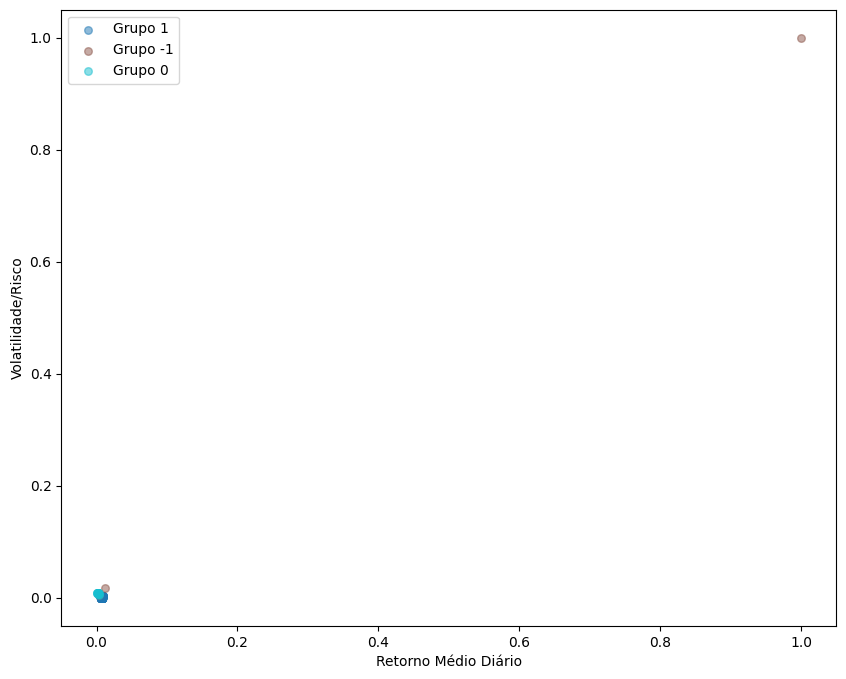

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
#ler arquvivo, mostrar cabeçalho e mostrar os grupos do hdbscan
df = pd.read_csv('/content/matriz_final_sem_dias')
print(df.head())
grupos = df['cluster_hdbscan'].unique()
print(grupos)
#normalizar o grafico
cols_normalizar = ['RETORNO_MEDIO_DIARIO', 'VOLATILIDADE_RISCO']
for col in cols_normalizar:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col + '_norm'] = (df[col] - min_val) / (max_val - min_val)
fig, ax = plt.subplots(figsize=(10, 8))
cores = plt.cm.tab10(np.linspace(0, 1, len(grupos)))
#constroi o grafico
for i, grupo in enumerate(grupos):
    df_grupo = df[df['cluster_hdbscan'] == grupo]
    print(f"Grupo {grupo}: {len(df_grupo)} membros")

    ax.scatter(
        df_grupo['RETORNO_MEDIO_DIARIO_norm'],
        df_grupo['VOLATILIDADE_RISCO_norm'],
        color=cores[i],
        label=f'Grupo {grupo}',
        alpha=0.5,
        s=30
    )

ax.set_xlabel('Retorno Médio Diário')
ax.set_ylabel('Volatilidade/Risco')
ax.legend()
plt.show()